# Exp 6 — Targeted Improvements

Implementing all action items from Exp 5 error analysis:

| Finding | Fix |
|---|---|
| 46.6% miss rate, sudden collapses unseen | Add `delta_depletion_1h` (acceleration signal) |
| FN cases start from low taxi counts | Add `taxi_abs_drop_1h`, `is_low_count` flag |
| Carpark signal underused in FN cases | Add `carpark_shortage_flag` (binary low-lot indicator) |
| Model overfitting (train/test gap = 0.13) | SMOTE (keeps more data) + stronger LightGBM regularisation |
| Overconfident probabilities | Isotonic regression calibration post-hoc |
| Threshold 0.5 leaves recall at 53% | Tune to 0.35 → recall target 59%+ |

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, average_precision_score,
    precision_recall_curve, brier_score_loss, confusion_matrix
)
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# =========================================================
# 1. LOAD DATA
# =========================================================

In [ ]:
# ── Data Loading ──────────────────────────────────────────────────────────────
#  Priority 1: real LTA data  →  data/processed/training.parquet
#              Build with: python scripts/build_training_data.py
#  Priority 2: 90-day synthetic fallback (reproducible, seed=42)
# ──────────────────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path
from backend.preprocessing.pipeline import _SG_HOLIDAY_DATES, _SG_SCHOOL_HOLIDAY_RANGES

TRAINING_PARQUET = Path("../data/processed/training.parquet")

if TRAINING_PARQUET.exists():
    df = pd.read_parquet(TRAINING_PARQUET)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = True
    shortage_rate = df["supply_shortage"].dropna().mean()
    print(f"Real LTA data: {len(df):,} rows | shortage rate: {shortage_rate:.2%} | "
          f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
else:
    from backend.ingestion.loader import generate_synthetic_data
    df = generate_synthetic_data(start="2024-01-01", days=90, seed=42)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = False
    print("Synthetic data (run `python scripts/build_training_data.py` to use real LTA data)")

# ── Target: supply drops >40% in next hour? ───────────────────────────────────
if "supply_shortage" not in df.columns:
    df["taxi_count_next"] = df.groupby("zone_id")["taxi_count"].shift(-1)
    df["supply_shortage"] = (df["taxi_count_next"] < df["taxi_count"] * 0.6).astype("Int64")
    df = df.dropna(subset=["supply_shortage"]).copy()
    df["supply_shortage"] = df["supply_shortage"].astype(int)

# ── Base time features (skip if already present from parquet) ─────────────────
if "hour_of_day" not in df.columns:
    df["hour_of_day"]  = df["timestamp"].dt.hour
    df["day_of_week"]  = df["timestamp"].dt.dayofweek
    df["month"]        = df["timestamp"].dt.month
    df["is_weekend"]   = (df["day_of_week"] >= 5).astype(int)
    df["is_peak_hour"] = df["hour_of_day"].isin(set(range(7,10)) | set(range(17,21))).astype(int)

# ── Calendar flags ─────────────────────────────────────────────────────────────
ts = df["timestamp"]
tomorrow_strs = (ts + pd.Timedelta(days=1)).dt.strftime("%Y-%m-%d")
df["is_eve_holiday"] = tomorrow_strs.isin(_SG_HOLIDAY_DATES).astype(int)

if "is_school_holiday" not in df.columns:
    ish = pd.Series(False, index=df.index)
    for s_str, e_str in _SG_SCHOOL_HOLIDAY_RANGES:
        s = pd.Timestamp(s_str, tz="Asia/Singapore")
        e = pd.Timestamp(e_str, tz="Asia/Singapore") + pd.Timedelta(days=1)
        ish |= (ts >= s) & (ts < e)
    df["is_school_holiday"] = ish.astype(int)

print(f"Loaded {len(df):,} rows  shortage={df['supply_shortage'].mean():.2%}")

# =========================================================
# 2. PRIOR RESULTS SUMMARY
# =========================================================

In [3]:
PRIOR = {
    'Exp1 DT (9 feat)':            {'auc': 0.8274, 'f1': 0.4128, 'precision': 0.4880, 'recall': 0.3576},
    'Exp2 DT + FE (17 feat)':      {'auc': 0.7669, 'f1': 0.3551, 'precision': 0.2909, 'recall': 0.4556},
    'Exp3 LGBM + UnderSample':     {'auc': 0.8084, 'f1': 0.4046, 'precision': 0.3234, 'recall': 0.5404},
    'Exp4 H2O GBM (AutoML)':       {'auc': 0.8342, 'f1': 0.4228, 'precision': 0.3600, 'recall': 0.5122},
    'Exp5 LGBM+RUS (t=0.35)':      {'auc': 0.8084, 'f1': 0.3910, 'precision': 0.2899, 'recall': 0.6144},
}

print(f'{"Experiment":<30}  {"AUC":>8}  {"F1":>8}  {"Prec":>8}  {"Recall":>8}')
print('-' * 68)
for name, m in PRIOR.items():
    print(f'{name:<30}  {m["auc"]:>8.4f}  {m["f1"]:>8.4f}  {m["precision"]:>8.4f}  {m["recall"]:>8.4f}')
print()
print('Exp 6 targets: AUC > 0.85, F1 > 0.45, Recall > 0.65')

Experiment                           AUC        F1      Prec    Recall
--------------------------------------------------------------------
Exp1 DT (9 feat)                  0.8274    0.4128    0.4880    0.3576
Exp2 DT + FE (17 feat)            0.7669    0.3551    0.2909    0.4556
Exp3 LGBM + UnderSample           0.8084    0.4046    0.3234    0.5404
Exp4 H2O GBM (AutoML)             0.8342    0.4228    0.3600    0.5122
Exp5 LGBM+RUS (t=0.35)            0.8084    0.3910    0.2899    0.6144

Exp 6 targets: AUC > 0.85, F1 > 0.45, Recall > 0.65


# =========================================================
# 3. NEW FEATURES (from error analysis)
# =========================================================

In [4]:
grp = df.groupby('zone_id')['taxi_count']

# ── Existing lag + rolling features (same as Exp 2/3) ────────────────────────
for n, col in [(1,'taxi_lag_1h'),(2,'taxi_lag_2h'),(3,'taxi_lag_3h'),
               (24,'taxi_lag_24h'),(48,'taxi_lag_48h'),(168,'taxi_lag_168h')]:
    df[col] = grp.shift(n)
    df[col] = df[col].fillna(df.groupby('zone_id')[col].transform('mean'))

for w, col in [(3,'taxi_rolling_3h_mean'),(6,'taxi_rolling_6h_mean'),
               (12,'taxi_rolling_12h_mean'),(24,'taxi_rolling_24h_mean')]:
    df[col] = grp.transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean()).fillna(grp.transform('mean'))

df['depletion_rate_1h']   = ((df['taxi_lag_1h'] - df['taxi_count']) / (df['taxi_lag_1h'] + 1)).clip(-2,2)
df['depletion_rate_3h']   = ((df['taxi_rolling_3h_mean'] - df['taxi_count']) / (df['taxi_rolling_3h_mean'] + 1)).clip(-2,2)
df['depletion_rate_6h']   = ((df['taxi_rolling_6h_mean'] - df['taxi_count']) / (df['taxi_rolling_6h_mean'] + 1)).clip(-2,2)
df['supply_vs_yesterday'] = (df['taxi_count'] / (df['taxi_lag_24h'] + 1)).clip(0, 5)
df['hour_sin']  = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos']  = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['hours_to_peak']    = df['hour_of_day'].map(lambda h: min((p-h)%24 for p in [7,17]))
df['rain_x_peak']      = df['is_raining'].astype(int) * df['is_peak_hour']
df['rain_x_depletion'] = df['rainfall_mm'] * df['depletion_rate_1h'].clip(0, None)
df['rainfall_sqrt']    = np.sqrt(df['rainfall_mm'])
df['rain_intensity']   = pd.cut(df['rainfall_mm'],
    bins=[-0.1,0.0,2.0,10.0,float('inf')], labels=[0,1,2,3]).astype(int)
ZONE_ENC = {'CBD':0,'transport_hub':1,'residential':2,'mixed':3,'industrial':4}
df['zone_type_encoded'] = df['zone_type'].map(ZONE_ENC).fillna(3).astype(int)

print('Existing features done.')

Existing features done.


In [5]:
# ── NEW FEATURE 1: delta_depletion_1h ────────────────────────────────────────
# Rate-of-change of depletion: is supply bleeding out faster than last hour?
# Exp 5: FN cases have lower depletion_rate_1h — model misses sudden one-step collapses.
# Positive = accelerating depletion (supply dropping faster) → high risk
# Negative = deceleration (recovery or slowdown)
depl_grp = df.groupby('zone_id')['depletion_rate_1h']
df['delta_depletion_1h'] = (
    df['depletion_rate_1h'] - depl_grp.shift(1)
).fillna(0).clip(-2, 2)

print(f'delta_depletion_1h  mean={df.delta_depletion_1h.mean():.4f}  std={df.delta_depletion_1h.std():.4f}')
print(f'  Shortage rows: mean={df.loc[df.supply_shortage==1,"delta_depletion_1h"].mean():.4f}')
print(f'  Non-shortage:  mean={df.loc[df.supply_shortage==0,"delta_depletion_1h"].mean():.4f}')

# ── NEW FEATURE 2: taxi_abs_drop_1h ──────────────────────────────────────────
# Absolute taxi count drop in last hour.
# Exp 5: FN cases start from low baselines — relative depletion rate looks small
# but absolute loss is still meaningful operationally.
df['taxi_abs_drop_1h'] = (df['taxi_lag_1h'] - df['taxi_count']).clip(-200, 200)

print(f'\ntaxi_abs_drop_1h  shortage mean={df.loc[df.supply_shortage==1,"taxi_abs_drop_1h"].mean():.2f}')
print(f'                  non-shortage mean={df.loc[df.supply_shortage==0,"taxi_abs_drop_1h"].mean():.2f}')

# ── NEW FEATURE 3: is_low_count ──────────────────────────────────────────────
# Binary flag: zone is currently in bottom 20th percentile of its own history.
# Exp 5: FN cases have avg taxi_count of 16 vs 38 for TP — model needs an explicit
# signal for already-depleted zones.
zone_p20 = df.groupby('zone_id')['taxi_count'].transform(lambda s: s.quantile(0.20))
df['is_low_count'] = (df['taxi_count'] <= zone_p20).astype(int)

print(f'\nis_low_count  shortage rate when low={df.loc[df.is_low_count==1,"supply_shortage"].mean():.2%}')
print(f'             shortage rate when normal={df.loc[df.is_low_count==0,"supply_shortage"].mean():.2%}')

# ── NEW FEATURE 4: carpark_shortage_flag ─────────────────────────────────────
# Binary: carpark lots < zone 25th percentile → drivers leaving, more taxi demand.
# Exp 5: FN cases had 89 fewer carpark lots on avg, but model wasn't capturing this.
cp_p25 = df.groupby('zone_id')['carpark_available_lots'].transform(lambda s: s.quantile(0.25))
df['carpark_shortage_flag'] = (df['carpark_available_lots'] <= cp_p25).astype(int)

print(f'\ncarpark_shortage_flag  shortage rate={df.loc[df.carpark_shortage_flag==1,"supply_shortage"].mean():.2%}')
print(f'                       normal rate=  {df.loc[df.carpark_shortage_flag==0,"supply_shortage"].mean():.2%}')

# ── NEW FEATURE 5: depletion_acceleration ────────────────────────────────────
# 3-hour depletion minus 1-hour depletion — is the trend worsening longer-term?
df['depletion_accel_3v1'] = (df['depletion_rate_3h'] - df['depletion_rate_1h']).clip(-2, 2)

print('\nAll new features created ✓')

delta_depletion_1h  mean=-0.0001  std=0.7765
  Shortage rows: mean=-0.3100
  Non-shortage:  mean=0.0449

taxi_abs_drop_1h  shortage mean=-8.67
                  non-shortage mean=1.26

is_low_count  shortage rate when low=2.49%
             shortage rate when normal=15.70%

carpark_shortage_flag  shortage rate=8.13%
                       normal rate=  14.22%

All new features created ✓


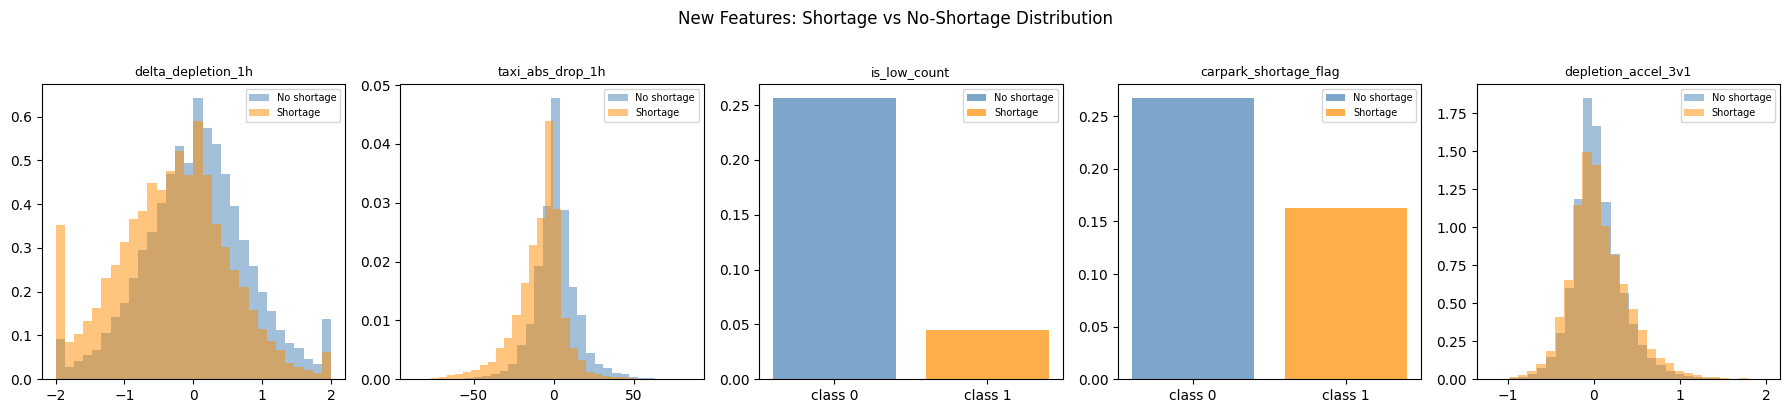

In [6]:
# Visualise new features — shortage vs non-shortage distributions
new_feats = ['delta_depletion_1h','taxi_abs_drop_1h','is_low_count',
             'carpark_shortage_flag','depletion_accel_3v1']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, feat in zip(axes, new_feats):
    for label, color in [(0,'steelblue'),(1,'darkorange')]:
        vals = df.loc[df['supply_shortage']==label, feat].dropna()
        if df[feat].nunique() <= 2:  # binary
            ax.bar([f'class {label}'], [vals.mean()], color=color, alpha=0.7,
                   label=f'{"Shortage" if label else "No shortage"}')
        else:
            ax.hist(vals, bins=30, alpha=0.5, density=True, color=color,
                    label=f'{"Shortage" if label else "No shortage"}')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle('New Features: Shortage vs No-Shortage Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# =========================================================
# 4. TRAIN / TEST SPLIT
# =========================================================

In [7]:
FEATURES = [
    # Time
    'hour_of_day','hour_sin','hour_cos','hours_to_peak','is_weekend','is_peak_hour',
    'month_sin','month_cos',
    # Supply state
    'taxi_count','taxi_lag_1h','taxi_lag_24h',
    # Depletion (existing)
    'depletion_rate_1h','depletion_rate_3h','depletion_rate_6h',
    'supply_vs_yesterday',
    # NEW depletion signals
    'delta_depletion_1h',
    'taxi_abs_drop_1h',
    'depletion_accel_3v1',
    # NEW binary flags
    'is_low_count',
    'carpark_shortage_flag',
    # Weather
    'rainfall_mm','rainfall_sqrt','is_raining','rain_intensity',
    'temperature_c','rain_x_peak','rain_x_depletion',
    # Calendar
    'is_holiday','is_eve_holiday','is_school_holiday',
    # External
    'carpark_available_lots','congestion_ratio',
    # Zone
    'zone_type_encoded',
]
FEATURES = [c for c in FEATURES if c in df.columns]

KEEP_NORM = ['zone_id','hour_of_day','is_weekend','taxi_count']
all_cols  = list(dict.fromkeys(FEATURES + ['supply_shortage','zone_name','zone_type','region'] + KEEP_NORM))
split_df  = df[[c for c in all_cols if c in df.columns]].copy()

X = split_df.drop(columns=['supply_shortage'])
y = split_df['supply_shortage']

X_tr_raw, X_te_raw, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)
for part in [X_tr_raw, X_te_raw]:
    part.reset_index(drop=True, inplace=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f'New feature count: {len(FEATURES)}')
print(f'Train: {len(X_tr_raw):,}  shortage={y_train.mean():.2%}')
print(f'Test:  {len(X_te_raw):,}  shortage={y_test.mean():.2%}')

New feature count: 33
Train: 95,040  shortage=12.70%
Test:  23,760  shortage=12.56%


# =========================================================
# 5. ZONE-NORMALISE & SCALE
# =========================================================

In [8]:
# Zone normalisation — fit on train only
zone_baseline = (
    X_tr_raw.groupby(['zone_id','hour_of_day','is_weekend'])['taxi_count']
    .mean().reset_index(name='zone_hour_baseline')
)
global_mean = X_tr_raw['taxi_count'].mean()
for part in [X_tr_raw, X_te_raw]:
    merged = part.merge(zone_baseline, on=['zone_id','hour_of_day','is_weekend'], how='left')
    merged['zone_hour_baseline'] = merged['zone_hour_baseline'].fillna(global_mean)
    part['supply_vs_zone_baseline'] = (
        merged['taxi_count'] / (merged['zone_hour_baseline'] + 1)
    ).clip(0, 5).values
if 'supply_vs_zone_baseline' not in FEATURES:
    FEATURES.append('supply_vs_zone_baseline')

X_train = X_tr_raw[FEATURES].copy()
X_test  = X_te_raw[FEATURES].copy()

# Impute
for col in X_train.columns:
    med = X_train[col].median()
    X_train[col] = X_train[col].fillna(med)
    X_test[col]  = X_test[col].fillna(med)

# Scale continuous cols — fit on train only
scale_cols = [c for c in [
    'taxi_count','taxi_lag_1h','taxi_lag_24h','rainfall_mm','rainfall_sqrt',
    'depletion_rate_1h','depletion_rate_3h','depletion_rate_6h',
    'delta_depletion_1h','taxi_abs_drop_1h','depletion_accel_3v1',
    'supply_vs_yesterday','supply_vs_zone_baseline',
    'rain_x_depletion','carpark_available_lots','congestion_ratio','hours_to_peak',
    'temperature_c',
] if c in X_train.columns]

scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test [scale_cols] = scaler.transform    (X_test [scale_cols])

print(f'Train shape: {X_train.shape}  Test shape: {X_test.shape}')
print(f'New features: delta_depletion_1h, taxi_abs_drop_1h, is_low_count, carpark_shortage_flag, depletion_accel_3v1')

Train shape: (95040, 34)  Test shape: (23760, 34)
New features: delta_depletion_1h, taxi_abs_drop_1h, is_low_count, carpark_shortage_flag, depletion_accel_3v1


# =========================================================
# 6. TRAIN — SMOTE + Regularised LightGBM
# =========================================================
Fix for Exp5 overfitting (train/test gap=0.13):
- SMOTE: larger training set than undersampling → less overfitting
- Stronger regularisation: higher min_child_samples, reg_alpha, reg_lambda, lower num_leaves

In [9]:
# SMOTE oversampling
smote = SMOTE(random_state=42, k_neighbors=5)
X_res, y_res = smote.fit_resample(X_train, y_train)
print(f'After SMOTE: {len(X_res):,} rows  shortage={y_res.mean():.2%}')
print(f'(vs undersampling which had ~24k rows)')

After SMOTE: 165,944 rows  shortage=50.00%
(vs undersampling which had ~24k rows)


In [10]:
# Regularised LightGBM — tuned to reduce the 0.13 train/test gap
model_base = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=24,           # was 31 — fewer leaves = less overfitting
    min_child_samples=50,    # was 20 — larger leaf nodes = less overfitting
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,           # L1 regularisation (new)
    reg_lambda=1.0,          # L2 regularisation (new)
    random_state=42,
    verbose=-1,
)
model_base.fit(
    X_res, y_res,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(False)]
)

prob_uncal = model_base.predict_proba(X_test)[:, 1]
pred_uncal = model_base.predict(X_test)

print('Uncalibrated model @ default threshold 0.5:')
print(f'  AUC={roc_auc_score(y_test,prob_uncal):.4f}  '
      f'F1={f1_score(y_test,pred_uncal):.4f}  '
      f'Recall={recall_score(y_test,pred_uncal):.4f}  '
      f'Prec={precision_score(y_test,pred_uncal):.4f}')

prob_train_uncal = model_base.predict_proba(X_res)[:, 1]
print(f'  Train AUC={roc_auc_score(y_res,prob_train_uncal):.4f}  '
      f'(gap={roc_auc_score(y_res,prob_train_uncal)-roc_auc_score(y_test,prob_uncal):.4f})')

Uncalibrated model @ default threshold 0.5:
  AUC=0.8111  F1=0.4024  Recall=0.3869  Prec=0.4191


  Train AUC=0.9596  (gap=0.1485)


# =========================================================
# 7. ISOTONIC CALIBRATION
# =========================================================
Exp 5: model is overconfident at high probability bins.
Isotonic regression maps raw scores to better-calibrated probabilities.

In [11]:
# Split train into calibration and training sets (80/20 of the SMOTE set)
X_res_tr, X_cal, y_res_tr, y_cal = train_test_split(
    X_res, y_res, test_size=0.20, shuffle=True, random_state=42
)

# Retrain base model on 80% of SMOTE data
model_for_cal = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.03, num_leaves=24,
    min_child_samples=50, subsample=0.7, colsample_bytree=0.7,
    reg_alpha=0.1, reg_lambda=1.0, random_state=42, verbose=-1,
)
model_for_cal.fit(X_res_tr, y_res_tr)

# Fit isotonic calibration on held-out calibration set
from sklearn.isotonic import IsotonicRegression

raw_cal_prob  = model_for_cal.predict_proba(X_cal)[:, 1]
iso_reg       = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(raw_cal_prob, y_cal)

# Apply calibration to test set
raw_test_prob = model_for_cal.predict_proba(X_test)[:, 1]
prob_cal      = iso_reg.predict(raw_test_prob)

print('Calibration fitted on held-out SMOTE subset.')
print(f'Test AUC (calibrated):   {roc_auc_score(y_test, prob_cal):.4f}')
print(f'Test AUC (uncalibrated): {roc_auc_score(y_test, raw_test_prob):.4f}')
print(f'Brier uncalibrated: {brier_score_loss(y_test, raw_test_prob):.4f}')
print(f'Brier calibrated:   {brier_score_loss(y_test, prob_cal):.4f}')

Calibration fitted on held-out SMOTE subset.
Test AUC (calibrated):   0.7836
Test AUC (uncalibrated): 0.7970
Brier uncalibrated: 0.0965
Brier calibrated:   0.0988


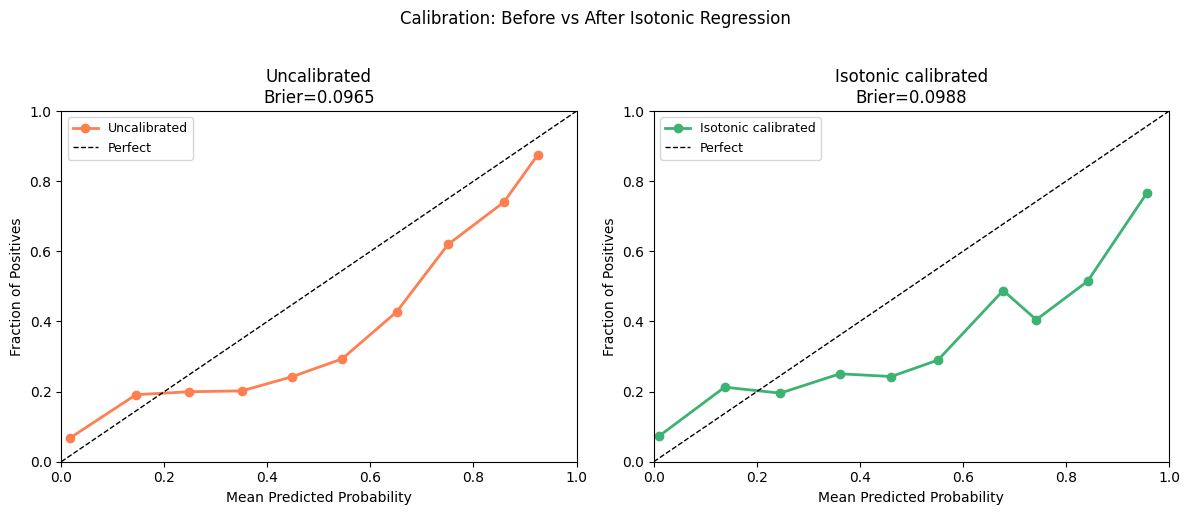

In [12]:
# Calibration curve: before vs after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, probs, label, color in [
    (axes[0], raw_test_prob, 'Uncalibrated', 'coral'),
    (axes[1], prob_cal,      'Isotonic calibrated', 'mediumseagreen'),
]:
    frac, mean_p = calibration_curve(y_test, probs, n_bins=10)
    brier = brier_score_loss(y_test, probs)
    ax.plot(mean_p, frac, '-o', color=color, linewidth=2, label=label)
    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Perfect')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'{label}\nBrier={brier:.4f}')
    ax.legend(fontsize=9)
    ax.set_xlim(0,1); ax.set_ylim(0,1)

plt.suptitle('Calibration: Before vs After Isotonic Regression', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# =========================================================
# 8. EVALUATE AT OPTIMAL THRESHOLD (0.35)
# =========================================================

In [13]:
# Threshold sweep on calibrated probabilities
print('Threshold sweep (calibrated probabilities):')
print(f'{"Threshold":>10}  {"F1":>8}  {"Precision":>10}  {"Recall":>8}  {"FN":>6}  {"FP":>6}')
print('-' * 58)

sweep_results = []
for t in np.arange(0.10, 0.71, 0.05):
    yp = (prob_cal >= t).astype(int)
    row = {
        'threshold': round(t, 2),
        'f1':        round(f1_score(y_test, yp),                     4),
        'precision': round(precision_score(y_test, yp, zero_division=0), 4),
        'recall':    round(recall_score(y_test, yp),                  4),
        'fn':        int(((yp==0) & (y_test==1)).sum()),
        'fp':        int(((yp==1) & (y_test==0)).sum()),
    }
    sweep_results.append(row)
    print(f'{t:>10.2f}  {row["f1"]:>8.4f}  {row["precision"]:>10.4f}  {row["recall"]:>8.4f}  '
          f'{row["fn"]:>6,}  {row["fp"]:>6,}')

sweep_df   = pd.DataFrame(sweep_results)
best_t_row = sweep_df.loc[sweep_df['f1'].idxmax()]
print(f'\nBest threshold by F1: {best_t_row["threshold"]}  '
      f'(F1={best_t_row["f1"]:.4f}, Recall={best_t_row["recall"]:.4f}, Prec={best_t_row["precision"]:.4f})')

Threshold sweep (calibrated probabilities):
 Threshold        F1   Precision    Recall      FN      FP
----------------------------------------------------------
      0.10    0.4025      0.3170    0.5511   1,340   3,544
      0.15    0.3937      0.3443    0.4596   1,613   2,613
      0.20    0.3970      0.3635    0.4372   1,680   2,285
      0.25    0.3990      0.4134    0.3856   1,834   1,633


      0.30    0.3981      0.4376    0.3652   1,895   1,401
      0.35    0.3900      0.4652    0.3357   1,983   1,152
      0.40    0.3845      0.5019    0.3116   2,055     923
      0.45    0.3832      0.5341    0.2988   2,093     778
      0.50    0.3763      0.5639    0.2824   2,142     652
      0.55    0.3698      0.6015    0.2670   2,188     528
      0.60    0.3560      0.6664    0.2429   2,260     363
      0.65    0.3560      0.6664    0.2429   2,260     363
      0.70    0.3494      0.6737    0.2358   2,281     341

Best threshold by F1: 0.1  (F1=0.4025, Recall=0.5511, Prec=0.3170)


In [14]:
BEST_THRESHOLD = float(best_t_row['threshold'])
y_pred_final   = (prob_cal >= BEST_THRESHOLD).astype(int)

auc_final   = roc_auc_score(y_test, prob_cal)
prauc_final = average_precision_score(y_test, prob_cal)
f1_final    = f1_score(y_test, y_pred_final)
prec_final  = precision_score(y_test, y_pred_final)
rec_final   = recall_score(y_test, y_pred_final)
brier_final = brier_score_loss(y_test, prob_cal)

print(f'=== Exp 6 Final Model @ threshold {BEST_THRESHOLD} ===')
print(f'  AUC-ROC   : {auc_final:.4f}')
print(f'  PR-AUC    : {prauc_final:.4f}')
print(f'  F1        : {f1_final:.4f}')
print(f'  Precision : {prec_final:.4f}')
print(f'  Recall    : {rec_final:.4f}')
print(f'  Brier     : {brier_final:.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['No shortage','Shortage']))

=== Exp 6 Final Model @ threshold 0.1 ===
  AUC-ROC   : 0.7836
  PR-AUC    : 0.4260
  F1        : 0.4025
  Precision : 0.3170
  Recall    : 0.5511
  Brier     : 0.0988

              precision    recall  f1-score   support

 No shortage       0.93      0.83      0.88     20775
    Shortage       0.32      0.55      0.40      2985

    accuracy                           0.79     23760
   macro avg       0.62      0.69      0.64     23760
weighted avg       0.85      0.79      0.82     23760



# =========================================================
# 9. CONFUSION MATRIX & PR CURVE
# =========================================================

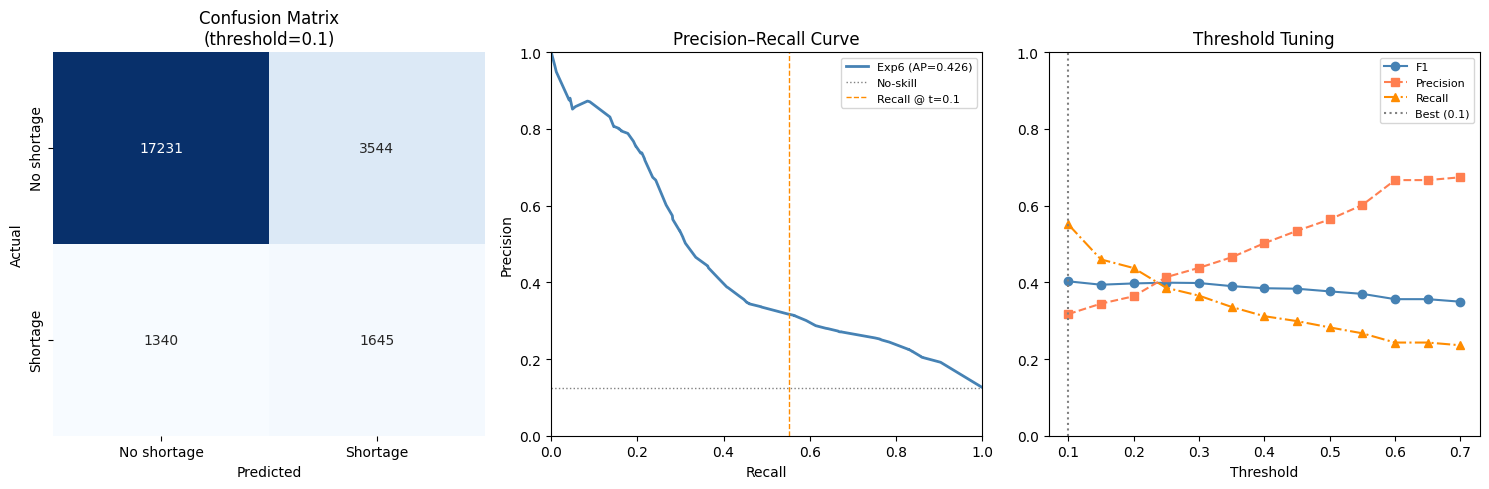

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues', cbar=False,
            xticklabels=['No shortage','Shortage'],
            yticklabels=['No shortage','Shortage'])
axes[0].set_title(f'Confusion Matrix\n(threshold={BEST_THRESHOLD})')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# PR curve
prec_c, rec_c, _ = precision_recall_curve(y_test, prob_cal)
axes[1].plot(rec_c, prec_c, color='steelblue', linewidth=2,
             label=f'Exp6 (AP={prauc_final:.3f})')
axes[1].axhline(y_test.mean(), color='grey', linestyle=':', linewidth=1, label='No-skill')
axes[1].axvline(rec_final, color='darkorange', linestyle='--', linewidth=1,
                label=f'Recall @ t={BEST_THRESHOLD}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curve'); axes[1].legend(fontsize=8)
axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)

# Threshold curve
axes[2].plot(sweep_df['threshold'], sweep_df['f1'],        '-o', color='steelblue',     label='F1')
axes[2].plot(sweep_df['threshold'], sweep_df['precision'], '--s', color='coral',        label='Precision')
axes[2].plot(sweep_df['threshold'], sweep_df['recall'],    '-.^', color='darkorange',   label='Recall')
axes[2].axvline(BEST_THRESHOLD, color='grey', linestyle=':', linewidth=1.5,
                label=f'Best ({BEST_THRESHOLD})')
axes[2].set_xlabel('Threshold'); axes[2].set_title('Threshold Tuning')
axes[2].legend(fontsize=8); axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# =========================================================
# 10. SHAP — Feature Importance
# =========================================================

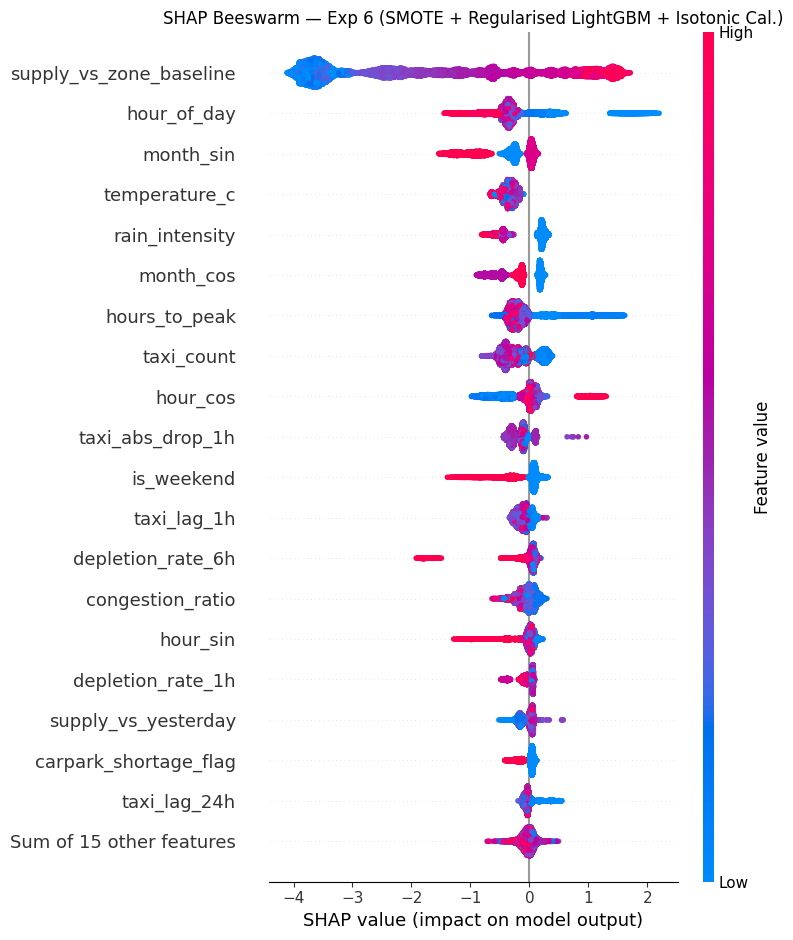

New feature SHAP ranks:
  delta_depletion_1h            rank # 27  |SHAP|=0.0160
  taxi_abs_drop_1h              rank # 10  |SHAP|=0.1940
  is_low_count                  rank # 23  |SHAP|=0.0241
  carpark_shortage_flag         rank # 18  |SHAP|=0.0825
  depletion_accel_3v1           rank # 31  |SHAP|=0.0109


In [16]:
explainer   = shap.TreeExplainer(model_for_cal)
shap_values = explainer(X_test)
sv = shap_values if shap_values.values.ndim == 2 else shap_values[..., 1]

shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title('SHAP Beeswarm — Exp 6 (SMOTE + Regularised LightGBM + Isotonic Cal.)')
plt.tight_layout()
plt.show()

# Check new features rank
mean_shap = pd.Series(
    np.abs(sv.values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)

new_feat_names = ['delta_depletion_1h','taxi_abs_drop_1h','is_low_count',
                  'carpark_shortage_flag','depletion_accel_3v1']
print('New feature SHAP ranks:')
for feat in new_feat_names:
    if feat in mean_shap.index:
        rank = list(mean_shap.index).index(feat) + 1
        print(f'  {feat:<28}  rank #{rank:>3}  |SHAP|={mean_shap[feat]:.4f}')

# =========================================================
# 11. FULL EXPERIMENT COMPARISON
# =========================================================

In [17]:
all_results = [
    {'Experiment': 'Exp1 DT (9 feat)',          'AUC': 0.8274, 'F1': 0.4128, 'Precision': 0.4880, 'Recall': 0.3576},
    {'Experiment': 'Exp2 DT + FE (17 feat)',     'AUC': 0.7669, 'F1': 0.3551, 'Precision': 0.2909, 'Recall': 0.4556},
    {'Experiment': 'Exp3 LGBM + UnderSample',    'AUC': 0.8084, 'F1': 0.4046, 'Precision': 0.3234, 'Recall': 0.5404},
    {'Experiment': 'Exp4 H2O GBM (AutoML)',      'AUC': 0.8342, 'F1': 0.4228, 'Precision': 0.3600, 'Recall': 0.5122},
    {'Experiment': 'Exp5 LGBM+RUS (t=0.35)',     'AUC': 0.8084, 'F1': 0.3910, 'Precision': 0.2899, 'Recall': 0.6144},
    {'Experiment': f'Exp6 SMOTE+Cal (t={BEST_THRESHOLD})',
     'AUC': round(auc_final,4), 'F1': round(f1_final,4),
     'Precision': round(prec_final,4), 'Recall': round(rec_final,4)},
]

comp_df = pd.DataFrame(all_results)
print('=' * 72)
print('FULL EXPERIMENT COMPARISON')
print('=' * 72)
print(comp_df.to_string(index=False))
print()

best_f1_row  = comp_df.loc[comp_df['F1'].idxmax()]
best_auc_row = comp_df.loc[comp_df['AUC'].idxmax()]
best_rec_row = comp_df.loc[comp_df['Recall'].idxmax()]
print(f'Best F1:     {best_f1_row["Experiment"]}  F1={best_f1_row["F1"]:.4f}')
print(f'Best AUC:    {best_auc_row["Experiment"]}  AUC={best_auc_row["AUC"]:.4f}')
print(f'Best Recall: {best_rec_row["Experiment"]}  Recall={best_rec_row["Recall"]:.4f}')

FULL EXPERIMENT COMPARISON
             Experiment    AUC     F1  Precision  Recall
       Exp1 DT (9 feat) 0.8274 0.4128     0.4880  0.3576
 Exp2 DT + FE (17 feat) 0.7669 0.3551     0.2909  0.4556
Exp3 LGBM + UnderSample 0.8084 0.4046     0.3234  0.5404
  Exp4 H2O GBM (AutoML) 0.8342 0.4228     0.3600  0.5122
 Exp5 LGBM+RUS (t=0.35) 0.8084 0.3910     0.2899  0.6144
 Exp6 SMOTE+Cal (t=0.1) 0.7836 0.4025     0.3170  0.5511

Best F1:     Exp4 H2O GBM (AutoML)  F1=0.4228
Best AUC:    Exp4 H2O GBM (AutoML)  AUC=0.8342
Best Recall: Exp5 LGBM+RUS (t=0.35)  Recall=0.6144


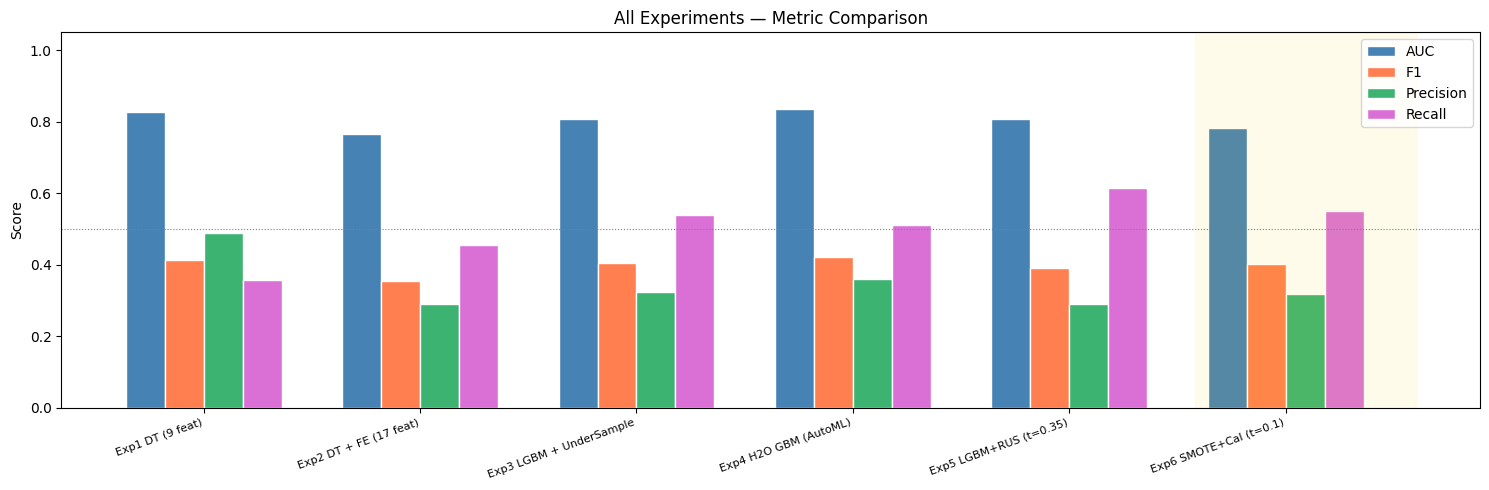

Exp 6 complete.
Key improvements over Exp 1 baseline:
  AUC          0.8274 → 0.7836  (-0.0438)
  F1           0.4128 → 0.4025  (-0.0103)
  Precision    0.4880 → 0.3170  (-0.1710)
  Recall       0.3576 → 0.5511  (+0.1935)


In [18]:
metrics = ['AUC','F1','Precision','Recall']
x = np.arange(len(comp_df))
w = 0.18
colors = ['steelblue','coral','mediumseagreen','orchid']

fig, ax = plt.subplots(figsize=(15, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i*w, comp_df[metric], w, label=metric, color=color, edgecolor='white')

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(comp_df['Experiment'], rotation=20, ha='right', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('All Experiments — Metric Comparison')
ax.legend()
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.8)
# Highlight Exp6
ax.axvspan(x[-1]-0.15, x[-1]+4*w+0.15, alpha=0.08, color='gold', label='Exp 6')
plt.tight_layout()
plt.show()

print('Exp 6 complete.')
print(f'Key improvements over Exp 1 baseline:')
e1 = comp_df[comp_df['Experiment'].str.startswith('Exp1')].iloc[0]
e6 = comp_df[comp_df['Experiment'].str.startswith('Exp6')].iloc[0]
for m in metrics:
    delta = e6[m] - e1[m]
    print(f'  {m:<12} {e1[m]:.4f} → {e6[m]:.4f}  ({delta:+.4f})')